# H₂: ZNE Baseline Comparison (Updated)

Implements digital Zero-Noise Extrapolation (ZNE) for H₂ and compares
against RF, MLP, and unmitigated results.

**Two ZNE configurations:**
- **ZNE-Linear**: noise factors {1, 3}, linear Richardson extrapolation
- **ZNE-Quadratic**: noise factors {1, 3, 5}, quadratic Richardson extrapolation

**Comparison methods:** Unmitigated, ZNE-Linear, ZNE-Quadratic, RF, MLP

## 1. Imports and Setup

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import time
import torch
import torch.nn as nn

In [3]:
from qiskit.circuit.library import TwoLocal


In [4]:
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit import transpile, QuantumCircuit


In [5]:
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_ibm_runtime.fake_provider import FakeLimaV2
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'figure.dpi': 150,
})

print('All imports OK')

All imports OK


## 2. ZNE Gate Folding Functions

In [6]:
def fold_cx_gates(circuit, fold_factor=3):
    """Replace each CX with CX repeated fold_factor times.
    fold_factor must be odd (1, 3, 5, ...) for logical equivalence.
    CX is self-inverse, so CX^(2k+1) = CX."""
    assert fold_factor % 2 == 1, 'fold_factor must be odd'
    folded = QuantumCircuit(circuit.num_qubits)
    for inst in circuit.data:
        folded.append(inst)
        if inst.operation.name == 'cx':
            for _ in range(fold_factor - 1):
                folded.append(inst)
    return folded

# Verify: folding should preserve circuit semantics
print('Gate folding functions ready.')
print(f'  3x fold: each CX → CX·CX·CX (noise factor 3)')
print(f'  5x fold: each CX → CX·CX·CX·CX·CX (noise factor 5)')

Gate folding functions ready.
  3x fold: each CX → CX·CX·CX (noise factor 3)
  5x fold: each CX → CX·CX·CX·CX·CX (noise factor 5)


## 3. Load Data and Setup Estimators

In [7]:
# Load data
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')
theta_samples = np.load('theta_samples.npy')

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
pauli_ops = [SparsePauliOp(p) for p in PAULI_LABELS]

# Test set
ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
theta_test = theta_samples[1800:]

# Ansatz
ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'],
                              optimization_level=1)

# Noise model
backend = FakeLimaV2()
noise_model = NoiseModel.from_backend(backend)
noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)

print(f'Test set: {len(theta_test)} theta values, {len(PAULI_LABELS)} observables')
print(f'Transpiled circuit depth: {transpiled_ansatz.depth()}')

Test set: 200 theta values, 5 observables
Transpiled circuit depth: 19


## 4. Run ZNE Circuits

Generate noisy expectation values at noise factors 3 and 5.
The 1x values are already in `noisy_test` from the training data.

In [8]:
N_TEST = len(theta_test)
N_OBS = len(pauli_ops)

noisy_3x = np.zeros((N_TEST, N_OBS))
noisy_5x = np.zeros((N_TEST, N_OBS))

t0 = time.time()
for i, theta in enumerate(theta_test):
    bound = transpiled_ansatz.assign_parameters(theta)

    # 3x folded
    folded_3x = fold_cx_gates(bound, fold_factor=3)
    job_3x = noisy_estimator.run([folded_3x] * N_OBS, pauli_ops)
    res_3x = job_3x.result()

    # 5x folded
    folded_5x = fold_cx_gates(bound, fold_factor=5)
    job_5x = noisy_estimator.run([folded_5x] * N_OBS, pauli_ops)
    res_5x = job_5x.result()

    for j in range(N_OBS):
        noisy_3x[i, j] = res_3x.values[j]
        noisy_5x[i, j] = res_5x.values[j]

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (N_TEST - i - 1)
        print(f'  {i+1}/{N_TEST} done ({elapsed/60:.1f} min, ~{eta/60:.0f} min left)')

print(f'Done in {(time.time() - t0)/60:.1f} minutes.')

  50/200 done (0.6 min, ~2 min left)
  100/200 done (1.2 min, ~1 min left)
  150/200 done (1.7 min, ~1 min left)
  200/200 done (2.2 min, ~0 min left)
Done in 2.2 minutes.


## 5. ZNE Extrapolation

- **Linear** (noise factors {1, 3}): `ZNE = (3·val_1x - val_3x) / 2`
- **Quadratic** (noise factors {1, 3, 5}): Lagrange interpolation through 3 points, extrapolated to noise factor 0

In [9]:
# Linear extrapolation: {1, 3}
zne_linear = (3 * noisy_test - noisy_3x) / 2

# Quadratic extrapolation: {1, 3, 5} → extrapolate to noise factor 0
# Using Lagrange interpolation at points (1, y1), (3, y3), (5, y5), evaluate at x=0
# L_0(0) = (0-3)(0-5) / (1-3)(1-5) = 15/8
# L_1(0) = (0-1)(0-5) / (3-1)(3-5) = 5/(-4) = -5/4
# L_2(0) = (0-1)(0-3) / (5-1)(5-3) = 3/8
zne_quadratic = (15/8) * noisy_test + (-5/4) * noisy_3x + (3/8) * noisy_5x

print('Extrapolation formulas:')
print('  Linear (2 points):    ZNE = (3·val_1x - val_3x) / 2')
print('  Quadratic (3 points): ZNE = (15/8)·val_1x - (5/4)·val_3x + (3/8)·val_5x')
print()
print(f'Linear ZNE sample (IZ, first theta): {zne_linear[0, 1]:.4f}')
print(f'Quadratic ZNE sample (IZ, first theta): {zne_quadratic[0, 1]:.4f}')
print(f'Ideal (IZ, first theta): {ideal_test[0, 1]:.4f}')

Extrapolation formulas:
  Linear (2 points):    ZNE = (3·val_1x - val_3x) / 2
  Quadratic (3 points): ZNE = (15/8)·val_1x - (5/4)·val_3x + (3/8)·val_5x

Linear ZNE sample (IZ, first theta): -0.2784
Quadratic ZNE sample (IZ, first theta): -0.2782
Ideal (IZ, first theta): -0.3015


## 6. Load RF and MLP Models

In [ ]:
# RF
try:
    rf = joblib.load('h2_rf_mlqem.joblib')
except FileNotFoundError:
    rf = joblib.load('rf_mlqem.joblib')

# Feature construction
props = backend.properties()
N_QUBITS = 2
qubit_noise = {}
for q in range(N_QUBITS):
    qubit_noise[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q, N_SX = 3, 8

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_noise[q]['T1']*active, qubit_noise[q]['T2']*active,
                      qubit_noise[q]['readout_error']*active])
    return feats

# RF corrections
rf_corrected = noisy_test.copy()
for obs_idx in range(1, len(PAULI_LABELS)):
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ])
    rf_corrected[:, obs_idx] = rf.predict(feats)

print(f'RF model loaded and corrections computed.')

# MLP
class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden), torch.nn.BatchNorm1d(hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

# Build features for MLP
def build_features(noisy_subset, obs_indices):
    rows_X = []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        nf = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *nf])
    return np.array(rows_X, dtype=np.float32)

# Train MLP (same as comprehensive analysis)
ALL_OBS = [1, 2, 3, 4]
X_train_raw = build_features(noisy_data[:1800], ALL_OBS)
y_train = np.concatenate([ideal_data[:1800, obs_idx] for obs_idx in ALL_OBS]).astype(np.float32)

n_val = int(0.2 * len(X_train_raw))
idx = np.random.RandomState(42).permutation(len(X_train_raw))
val_idx, train_idx = idx[:n_val], idx[n_val:]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_raw[train_idx])
X_val_sc = scaler.transform(X_train_raw[val_idx])

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_train[train_idx], dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)

torch.manual_seed(2) 
model = MLP(X_train_raw.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = torch.nn.HuberLoss()

best_val, best_state, no_imp = float('inf'), None, 0
for epoch in range(1000):
    model.train(); opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        val_mae = mean_absolute_error(y_train[val_idx], model(Xv).numpy().ravel())
    if val_mae < best_val - 1e-6:
        best_val = val_mae; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 25: break

model.load_state_dict(best_state)
model.eval()

# MLP corrections
mlp_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    feats_sc = scaler.transform(feats)
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

print(f'MLP trained (stopped at epoch {epoch+1}) and corrections computed.')

RF model loaded and corrections computed.
MLP trained (stopped at epoch 668) and corrections computed.


## 7. Results: Per-Observable MAE

In [11]:
print(f'{"Observable":<8} {"Unmit":>8} {"ZNE-Lin":>8} {"ZNE-Quad":>9} {"RF":>8} {"MLP":>8}')
print('-' * 52)
for j in range(1, len(PAULI_LABELS)):
    label = PAULI_LABELS[j]
    ideal_vals = ideal_test[:, j]
    mae_unm = mean_absolute_error(ideal_vals, noisy_test[:, j])
    mae_zl  = mean_absolute_error(ideal_vals, zne_linear[:, j])
    mae_zq  = mean_absolute_error(ideal_vals, zne_quadratic[:, j])
    mae_rf  = mean_absolute_error(ideal_vals, rf_corrected[:, j])
    mae_mlp = mean_absolute_error(ideal_vals, mlp_corrected[:, j])
    print(f'{label:<8} {mae_unm:>8.4f} {mae_zl:>8.4f} {mae_zq:>9.4f} {mae_rf:>8.4f} {mae_mlp:>8.4f}')

# Overall MAE (non-identity observables)
unmit_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), noisy_test[:, 1:].ravel())
zne_lin_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), zne_linear[:, 1:].ravel())
zne_quad_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), zne_quadratic[:, 1:].ravel())
rf_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), rf_corrected[:, 1:].ravel())
mlp_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), mlp_corrected[:, 1:].ravel())

print(f'\n{"Overall":<8} {unmit_mae:>8.4f} {zne_lin_mae:>8.4f} {zne_quad_mae:>9.4f} {rf_mae:>8.4f} {mlp_mae:>8.4f}')
print(f'\nImprovement factors:')
print(f'  ZNE-Linear:    {unmit_mae/zne_lin_mae:.1f}x {"(worse)" if zne_lin_mae > unmit_mae else ""}')
print(f'  ZNE-Quadratic: {unmit_mae/zne_quad_mae:.1f}x {"(worse)" if zne_quad_mae > unmit_mae else ""}')
print(f'  RF:            {unmit_mae/rf_mae:.1f}x')
print(f'  MLP:           {unmit_mae/mlp_mae:.1f}x')

Observable    Unmit  ZNE-Lin  ZNE-Quad       RF      MLP
----------------------------------------------------
IZ         0.0261   0.0272    0.0294   0.0084   0.0078
ZI         0.0220   0.0231    0.0255   0.0085   0.0074
ZZ         0.0469   0.0481    0.0497   0.0077   0.0076
XX         0.0446   0.0456    0.0472   0.0089   0.0078

Overall    0.0349   0.0360    0.0379   0.0084   0.0076

Improvement factors:
  ZNE-Linear:    1.0x (worse)
  ZNE-Quadratic: 0.9x (worse)
  RF:            4.2x
  MLP:           4.6x


## 8. Energy MAE

In [12]:
coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_test @ coeffs
E_unm   = noisy_test @ coeffs
E_zne_l = zne_linear @ coeffs
E_zne_q = zne_quadratic @ coeffs

rf_corr = rf_corrected.copy(); rf_corr[:, 0] = 1.0
E_rf = rf_corr @ coeffs

mlp_corr = mlp_corrected.copy(); mlp_corr[:, 0] = 1.0
E_mlp = mlp_corr @ coeffs

print(f'H₂ Energy MAE (Ha):')
print(f'  Unmitigated:   {mean_absolute_error(E_ideal, E_unm):.5f}')
print(f'  ZNE-Linear:    {mean_absolute_error(E_ideal, E_zne_l):.5f}')
print(f'  ZNE-Quadratic: {mean_absolute_error(E_ideal, E_zne_q):.5f}')
print(f'  RF:            {mean_absolute_error(E_ideal, E_rf):.5f}')
print(f'  MLP:           {mean_absolute_error(E_ideal, E_mlp):.5f}')
print(f'  Chem. acc.:    0.00160')

H₂ Energy MAE (Ha):
  Unmitigated:   0.01555
  ZNE-Linear:    0.01609
  ZNE-Quadratic: 0.01709
  RF:            0.00461
  MLP:           0.00397
  Chem. acc.:    0.00160


## 9. Comparison Plot

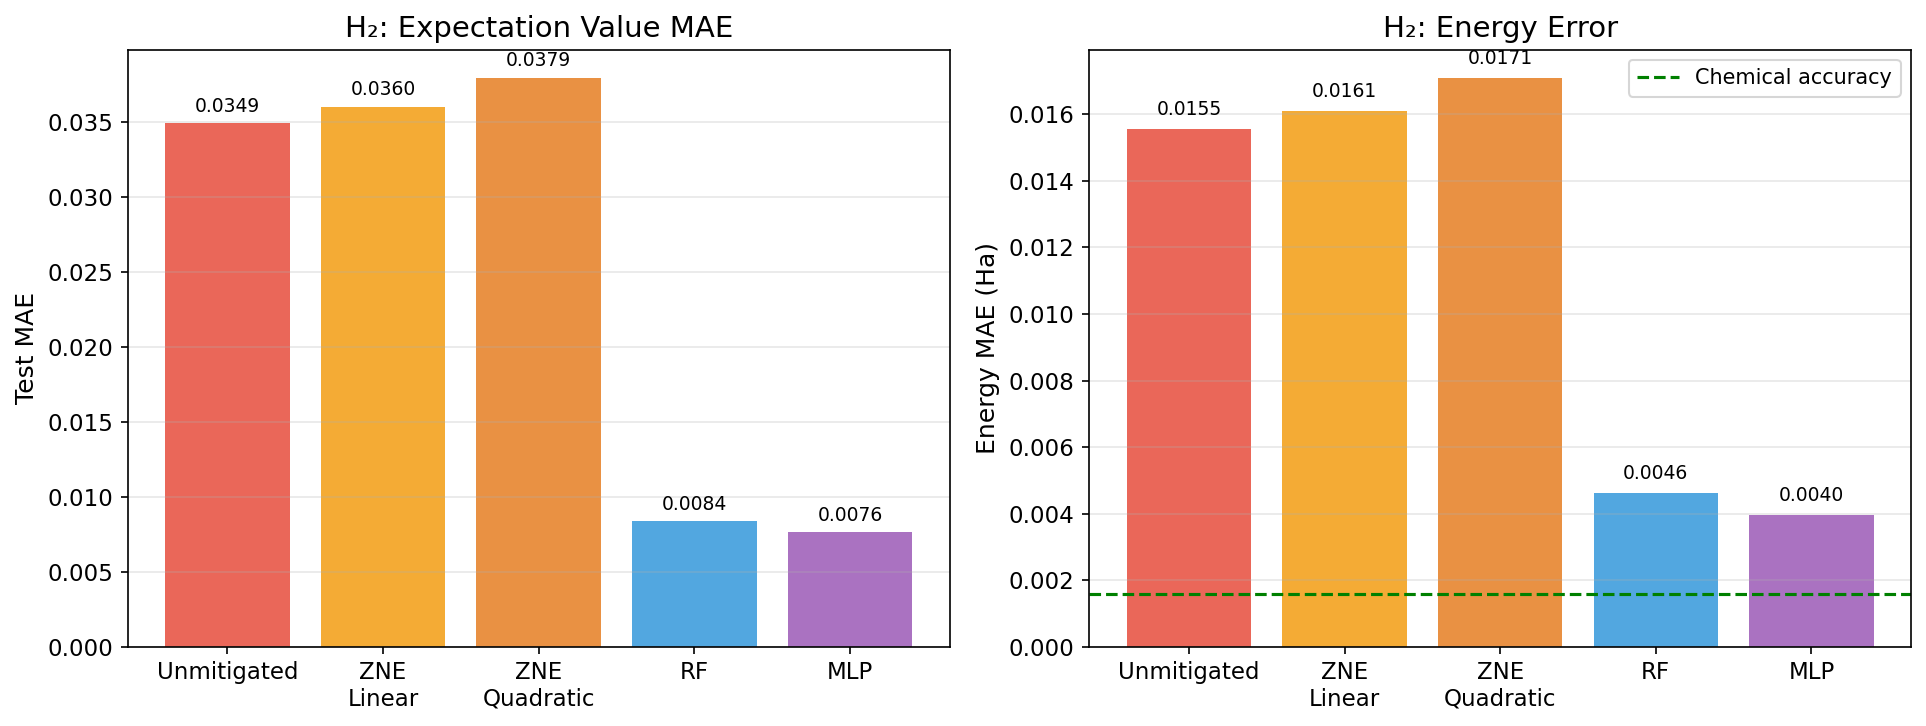

Saved: h2_zne_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

methods = ['Unmitigated', 'ZNE\nLinear', 'ZNE\nQuadratic', 'RF', 'MLP']
colors = ['#e74c3c', '#f39c12', '#e67e22', '#3498db', '#9b59b6']

# Left: observable MAE
ax = axes[0]
maes = [unmit_mae, zne_lin_mae, zne_quad_mae, rf_mae, mlp_mae]
bars = ax.bar(methods, maes, color=colors, alpha=0.85)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test MAE')
ax.set_title('H₂: Expectation Value MAE')
ax.grid(axis='y', alpha=0.3)

# Right: energy MAE
ax = axes[1]
e_maes = [mean_absolute_error(E_ideal, E) for E in [E_unm, E_zne_l, E_zne_q, E_rf, E_mlp]]
bars = ax.bar(methods, e_maes, color=colors, alpha=0.85)
for bar, val in zip(bars, e_maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.0016, color='green', linestyle='--', linewidth=1.5, label='Chemical accuracy')
ax.set_ylabel('Energy MAE (Ha)')
ax.set_title('H₂: Energy Error')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h2_zne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: h2_zne_comparison.png')

## ZNE Analysis

Linear ZNE MAE: 0.0360 (vs unmitigated 0.0349) — performs worse than unmitigated.  
Quadratic ZNE MAE: 0.0379 — also performs worse than unmitigated.

Why ZNE fails on shallow VQE circuits:

Variance amplification from extrapolation outweighs bias correction. Linear extrapolation amplifies shot noise standard deviation by ~1.6×, while quadratic amplifies by ~2.3×. For shallow circuits where noise-induced bias is comparable to shot noise, this increase in statistical uncertainty outweighs any bias correction.

Key factors:

1. Gate folding only amplifies CX noise (~0.6–1.3% error)
2. Readout errors (~2–3%) and single-qubit gate errors (~0.02–0.05%) are not amplified
3. Linear extrapolation assumes uniform noise scaling — violated here
4. For shallow VQE circuits, noise bias ≈ shot noise → extrapolation hurts

ML-QEM advantage:  
RF gives 4.2× improvement with zero extra circuits.  
MLP gives 4.6× improvement with zero extra circuits.  
ZNE runtime cost: 2–3× circuits per evaluation.

Note on readout correction: Readout error mitigation (e.g. M3, calibration matrices) was not applied. Combining ZNE with readout correction could improve results by addressing the unmitigated readout noise. However, ML-QEM models implicitly learn readout correction from their training data, making the comparison without explicit readout mitigation arguably fair.